In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [11]:
df = pd.read_csv("ADVENTURE_MICRO_FROM_SCIENTIST.csv")

In [12]:
df.shape

(1393, 5)

In [13]:
df.columns

Index(['Date', 'Latitude', 'Longitude', 'Total_Pieces_L', 'Normalized'], dtype='object')

In [14]:

df["Date"] = pd.to_datetime(df["Date"])


df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["quarter"] = df["Date"].dt.quarter
df["day_of_year"] = df["Date"].dt.dayofyear


print(df.columns)

df.head()

Index(['Date', 'Latitude', 'Longitude', 'Total_Pieces_L', 'Normalized', 'year',
       'month', 'quarter', 'day_of_year'],
      dtype='object')


,Date,Latitude,Longitude,Total_Pieces_L,Normalized,year,month,quarter,day_of_year
0,1970-01-01,63.221610,-41.405960,3,0.009288,1970,1,1,1
1,1970-01-01,63.470810,-41.934710,0,0.000000,1970,1,1,1
2,1970-01-01,65.610920,-37.645740,1,0.003096,1970,1,1,1
3,1970-01-01,9.958530,-84.891080,9,0.027864,1970,1,1,1
4,2013-07-01,59.378683,-153.520867,1,0.003096,2013,7,3,182


In [15]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nBasic Statistics:")
display(df.describe())

Dataset Shape: (1393, 9)

Data Types:
Date              datetime64[ns]
Latitude                 float64
Longitude                float64
Total_Pieces_L             int64
Normalized               float64
year                       int32
month                      int32
quarter                    int32
day_of_year                int32
dtype: object

Missing Values:
Date              0
Latitude          0
Longitude         0
Total_Pieces_L    0
Normalized        0
year              0
month             0
quarter           0
day_of_year       0
dtype: int64

Duplicate Rows: 1

Basic Statistics:


,Date,Latitude,Longitude,Total_Pieces_L,Normalized,year,month,quarter,day_of_year
count,1393,1393.000000,1393.000000,1393.000000,1393.000000,1393.000000,1393.000000,1393.000000,1393.000000
mean,2015-02-28 18:04:23.603732992,17.360050,-50.711904,12.750179,0.039474,2014.527638,8.158650,2.966260,232.160086
min,1970-01-01 00:00:00,-65.177500,-169.926130,0.000000,0.000000,1970.000000,1.000000,1.000000,1.000000
25%,2014-11-25 00:00:00,14.302333,-83.154150,1.000000,0.003096,2014.000000,5.000000,2.000000,127.000000
50%,2014-12-09 00:00:00,18.704733,-56.433333,4.000000,0.012384,2014.000000,10.000000,4.000000,277.000000
75%,2015-09-15 00:00:00,29.467000,-28.020000,12.000000,0.037152,2015.000000,11.000000,4.000000,333.000000
max,2017-03-30 00:00:00,81.090000,174.135000,323.000000,1.000000,2017.000000,12.000000,4.000000,366.000000
std,NaN,26.967994,66.246497,27.319984,0.084582,2.565687,3.784605,1.197283,114.821742


# **1. Latitude vs Microplastic Density**
Insights:

Microplastic density varies across different latitude locations.

Some latitude regions show higher concentration values than others.

There is no clear linear relationship between latitude and microplastic density.

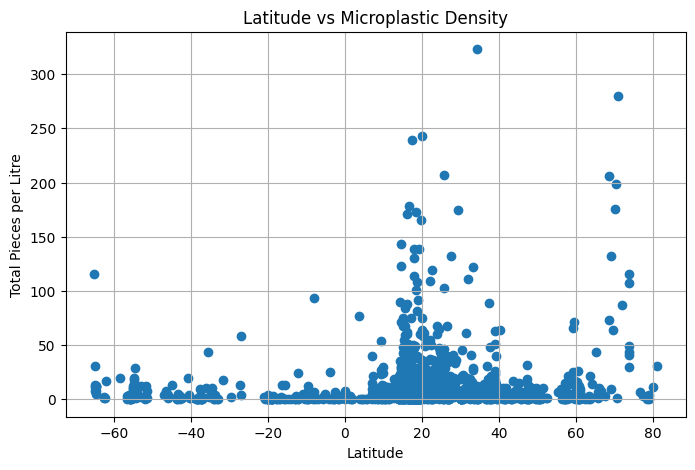

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(df["Latitude"], df["Total_Pieces_L"])
plt.title("Latitude vs Microplastic Density")
plt.xlabel("Latitude")
plt.ylabel("Total Pieces per Litre")
plt.grid(True)
plt.savefig("/content/latitude_vs_microplastic.png", dpi=300)
plt.show()

# **2. Longitude vs Microplastic Density**

Insights:

Microplastic density changes across different longitude locations.

Some geographical locations show noticeably higher concentration values.

There is no simple linear relationship between longitude and microplastic density.

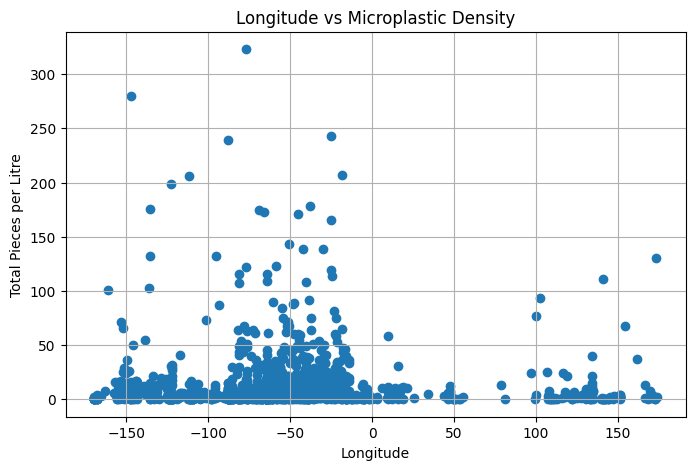

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(df["Longitude"], df["Total_Pieces_L"])
plt.title("Longitude vs Microplastic Density")
plt.xlabel("Longitude")
plt.ylabel("Total Pieces per Litre")
plt.grid(True)
plt.savefig("/content/longitude_vs_microplastic.png", dpi=300)
plt.show()

# **3. Monthly Average Microplastic Density**

Insights:

Average microplastic density varies across different months.

Some months show higher average concentration than others.

This indicates temporal variation in the observed microplastic density.

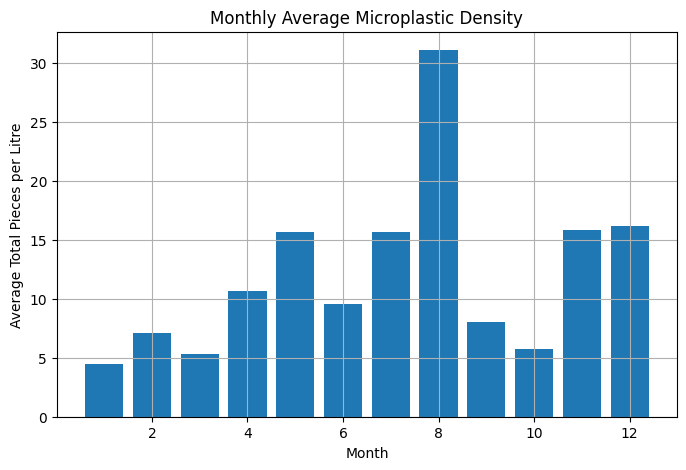

In [18]:
monthly_average = df.groupby("month")["Total_Pieces_L"].mean()

plt.figure(figsize=(8,5))
plt.bar(monthly_average.index, monthly_average.values)
plt.title("Monthly Average Microplastic Density")
plt.xlabel("Month")
plt.ylabel("Average Total Pieces per Litre")
plt.grid(True)
plt.savefig("/content/monthly_average_microplastic.png", dpi=300)
plt.show()

# **4. Microplastic Density Distribution**

Insights:

Most observations fall within a lower-to-middle concentration range.

A smaller number of observations show relatively high microplastic density.

The dataset contains noticeable variation in concentration values.

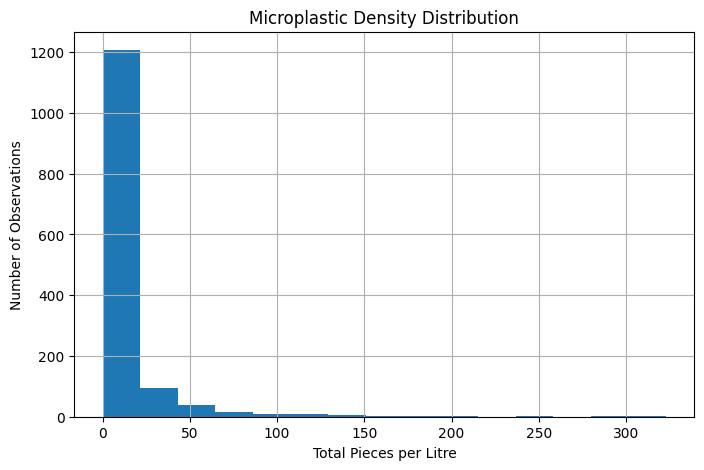

In [19]:
plt.figure(figsize=(8,5))
plt.hist(df["Total_Pieces_L"], bins=15)
plt.title("Microplastic Density Distribution")
plt.xlabel("Total Pieces per Litre")
plt.ylabel("Number of Observations")
plt.grid(True)
plt.savefig("/content/microplastic_density_distribution.png", dpi=300)
plt.show()

# **5. Microplastic Density Over Time**

Insights:

Microplastic density varies across different sampling dates.

Some dates show noticeably higher concentration values.

The observations indicate temporal variation in microplastic density.

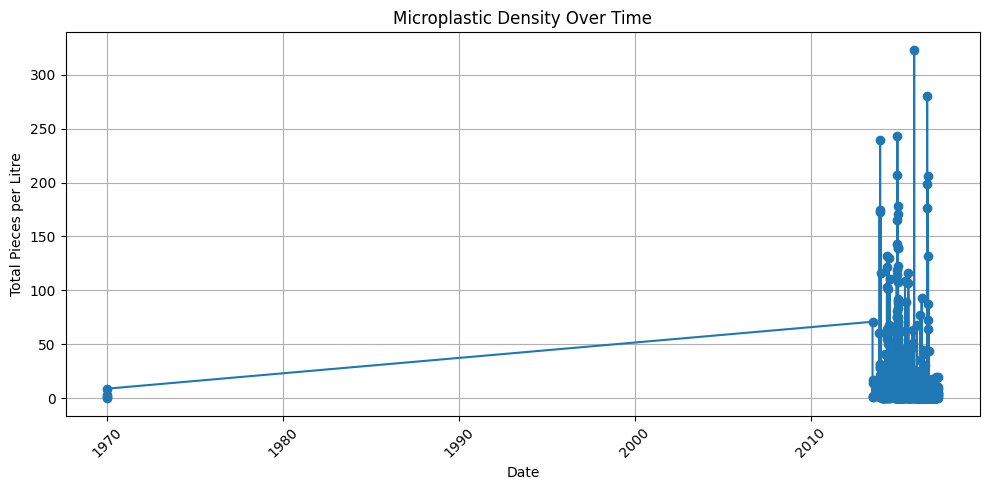

In [20]:
df_time = df.sort_values("Date")

plt.figure(figsize=(10,5))
plt.plot(df_time["Date"], df_time["Total_Pieces_L"], marker="o")
plt.title("Microplastic Density Over Time")
plt.xlabel("Date")
plt.ylabel("Total Pieces per Litre")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig("/content/microplastic_density_over_time.png", dpi=300)
plt.show()

# **6. Geographical Distribution of Sampling Locations**

Insights:

Sampling locations are distributed across different latitude and longitude regions.

The dataset covers multiple geographical locations.

The visualization provides an overview of the spatial coverage of the samples.

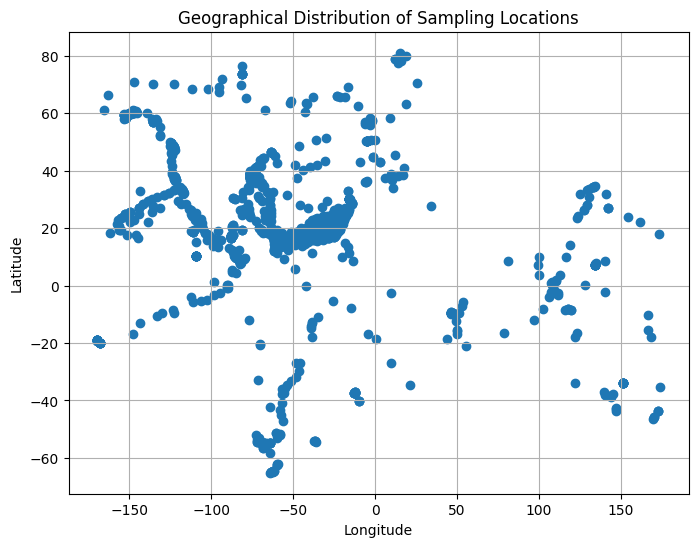

In [21]:
plt.figure(figsize=(8,6))
plt.scatter(df["Longitude"], df["Latitude"])
plt.title("Geographical Distribution of Sampling Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.savefig("/content/geographical_distribution.png", dpi=300)
plt.show()

# **7. Microplastic Density by Quarter**

Insights:

Average microplastic density differs across the four quarters.

Some quarters show higher average concentration than others.

Quarterly comparison helps identify broad temporal variation in the dataset.

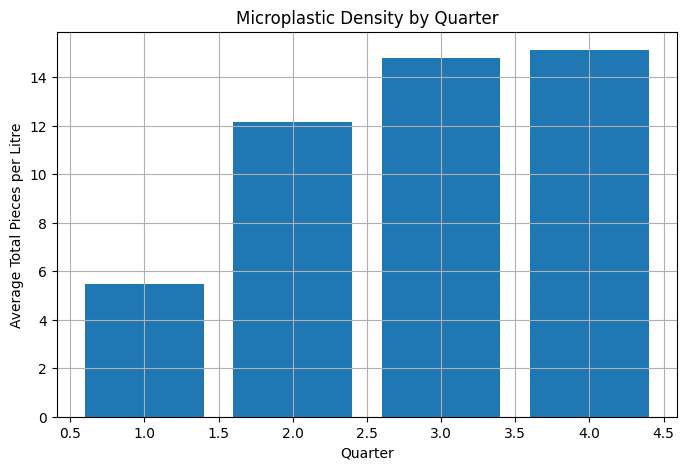

In [22]:
quarter_average = df.groupby("quarter")["Total_Pieces_L"].mean()

plt.figure(figsize=(8,5))
plt.bar(quarter_average.index, quarter_average.values)
plt.title("Microplastic Density by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Average Total Pieces per Litre")
plt.grid(True)
plt.savefig("/content/microplastic_density_by_quarter.png", dpi=300)
plt.show()